In [1]:
!pip install git+https://github.com/andreinechaev/nvcc4jupyter.git
%load_ext nvcc4jupyter

  Cloning https://github.com/andreinechaev/nvcc4jupyter.git to /tmp/pip-req-build-ey9r2i58
  Running command git clone --filter=blob:none --quiet https://github.com/andreinechaev/nvcc4jupyter.git /tmp/pip-req-build-ey9r2i58
  Resolved https://github.com/andreinechaev/nvcc4jupyter.git to commit 28f872a2f99a1b201bcd0db14fdbc5a496b9bfd7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for nvcc4jupyter: filename=nvcc4jupyter-1.2.1-py3-none-any.whl size=10741 sha256=90a829d54142cdbaf5703d6409de30ec0002408286cfbcd108dfdd84cf0ee4fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-afdkfmuw/wheels/7d/b9/66/459b9938664e6a93d1a85323ec52f7e51cd7265d253410a7d8
Successfully built nvcc4jupyter
Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpdt12207x".


In [2]:
!nvcc --version


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [3]:
%load_ext nvcc4jupyter

The nvcc4jupyter extension is already loaded. To reload it, use:
  %reload_ext nvcc4jupyter


In [4]:
from pathlib import Path

file_path = Path('/absolute/path/to/images.jpeg')
if file_path.exists():
    print("File exists!")
else:
    print("File does not exist!")


File does not exist!


In [5]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: /content


In [7]:
from google.colab import files
uploaded = files.upload()

Saving images.jpeg to images.jpeg


In [8]:
from pathlib import Path

# Assuming the file is in the same directory as the notebook
file_path = Path('images.jpeg')
if file_path.exists():
    print("File exists!")
else:
    print("File does not exist!")


File exists!


In [9]:
pwd


'/content'

In [10]:
ls /content/images.jpeg

/content/images.jpeg


In [11]:
#ls -l /content/images.jpeg
import cv2
image = cv2.imread('/content/images.jpeg')
if image is None:
    print("Error: Image not found or unable to read the image.")
else:
    print("Image read successfully.")


Image read successfully.


In [13]:
%%writefile sobelEdgeDetectionFilter.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <cuda_runtime.h>
#include <opencv2/opencv.hpp>

using namespace cv;

// ─────────────────────────────────────────────────────────────────────────────
// CUDA Kernel: sobelFilter
//   • Converts each pixel to grayscale (if colour) using luminosity weights
//   • Applies Sobel Gx and Gy kernels
//   • Boundary-checks so edge pixels are handled without out-of-bounds reads
// ─────────────────────────────────────────────────────────────────────────────
__global__ void sobelFilter(unsigned char *srcImage,
                             unsigned char *dstImage,
                             unsigned int   width,
                             unsigned int   height)
{
    // Compute the (x, y) position this thread handles
    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    // Boundary check – skip threads that fall outside the image
    if (x >= width || y >= height) return;

    // Sobel kernels
    //   Gx:  [-1  0  1]      Gy:  [-1 -2 -1]
    //        [-2  0  2]           [ 0  0  0]
    //        [-1  0  1]           [ 1  2  1]
    int Gx = 0, Gy = 0;

    for (int ky = -1; ky <= 1; ky++) {
        for (int kx = -1; kx <= 1; kx++) {
            // Clamp neighbour coordinates to valid range (handles image borders)
            int nx = min(max(x + kx, 0), (int)width  - 1);
            int ny = min(max(y + ky, 0), (int)height - 1);

            // The source image is stored as BGR (3 channels); convert to grey
            int idx   = (ny * width + nx) * 3;   // 3 bytes per pixel (BGR)
            int blue  = srcImage[idx    ];
            int green = srcImage[idx + 1];
            int red   = srcImage[idx + 2];
            // Luminosity / BT.601 weights
            int grey  = (int)(0.114f * blue + 0.587f * green + 0.299f * red);

            // Sobel weights for this kernel position
            int wx = (kx == -1 ? -1 : kx == 1 ? 1 : 0) * (ky == 0 ? 2 : 1);
            int wy = (ky == -1 ? -1 : ky == 1 ? 1 : 0) * (kx == 0 ? 2 : 1);

            Gx += wx * grey;
            Gy += wy * grey;
        }
    }

    // Gradient magnitude, clamped to [0, 255]
    int magnitude = (int)sqrtf((float)(Gx * Gx + Gy * Gy));
    dstImage[y * width + x] = (unsigned char)min(magnitude, 255);
}

// ─────────────────────────────────────────────────────────────────────────────
// Helper: check CUDA return codes
// ─────────────────────────────────────────────────────────────────────────────
void checkCudaErrors(cudaError_t r) {
    if (r != cudaSuccess) {
        fprintf(stderr, "CUDA Error: %s\n", cudaGetErrorString(r));
        exit(EXIT_FAILURE);
    }
}

// ─────────────────────────────────────────────────────────────────────────────
// main
// ─────────────────────────────────────────────────────────────────────────────
int main() {
    // ── 1. Read input image (colour) ──────────────────────────────────────────
    Mat image = imread("/content/images.jpeg", IMREAD_COLOR);
    if (image.empty()) {
        printf("Error: Image not found.\n");
        return -1;
    }

    int width     = image.cols;
    int height    = image.rows;
    // Input: 3-channel BGR  |  Output: 1-channel grayscale edge map
    size_t inputSize  = (size_t)width * height * 3 * sizeof(unsigned char);
    size_t outputSize = (size_t)width * height     * sizeof(unsigned char);

    printf("Image size: %d x %d\n", width, height);

    // ── 2. Allocate host output buffer ────────────────────────────────────────
    unsigned char *h_outputImage = (unsigned char *)malloc(outputSize);
    if (!h_outputImage) {
        fprintf(stderr, "Failed to allocate host memory\n");
        return -1;
    }

    // ── 3. Allocate device memory and copy input ──────────────────────────────
    unsigned char *d_inputImage, *d_outputImage;
    checkCudaErrors(cudaMalloc(&d_inputImage,  inputSize));
    checkCudaErrors(cudaMalloc(&d_outputImage, outputSize));
    checkCudaErrors(cudaMemcpy(d_inputImage, image.data, inputSize,
                               cudaMemcpyHostToDevice));

    // ── 4. CUDA timing events ─────────────────────────────────────────────────
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    // ── 5. Launch kernel (16×16 thread block) ─────────────────────────────────
    dim3 blockSize(16, 16);
    dim3 gridSize((int)ceil(width  / 16.0),
                  (int)ceil(height / 16.0));

    cudaEventRecord(start);
    sobelFilter<<<gridSize, blockSize>>>(d_inputImage, d_outputImage,
                                         width, height);
    cudaEventRecord(stop);

    // ── 6. Check for kernel launch errors ────────────────────────────────────
    checkCudaErrors(cudaGetLastError());
    cudaEventSynchronize(stop);

    float milliseconds = 0;
    cudaEventElapsedTime(&milliseconds, start, stop);
    printf("CUDA Sobel kernel execution time: %.4f ms\n", milliseconds);

    // ── 7. Copy result back to host ───────────────────────────────────────────
    checkCudaErrors(cudaMemcpy(h_outputImage, d_outputImage, outputSize,
                               cudaMemcpyDeviceToHost));

    // ── 8. Write output image ─────────────────────────────────────────────────
    Mat outputImage(height, width, CV_8UC1, h_outputImage);
    imwrite("output_sobel.jpeg", outputImage);
    printf("Output written to output_sobel.jpeg\n");

    // ── 9. Free resources ─────────────────────────────────────────────────────
    free(h_outputImage);
    cudaFree(d_inputImage);
    cudaFree(d_outputImage);
    cudaEventDestroy(start);
    cudaEventDestroy(stop);

    return 0;
}


Overwriting sobelEdgeDetectionFilter.cu


In [15]:
!apt-get install -y libopencv-dev
!pkg-config --modversion opencv4

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas gstreamer1.0-plugins-base
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0 libavcodec-dev
  libavformat-dev libavutil-dev libcdparanoia0 libcharls2 libdc1394-dev
  libdouble-conversion3 libexif-dev libexif-doc libexif12 libgdcm-dev
  libgdcm3.0 libgl2ps1.4 libglew2.2 libgphoto2-6 libgphoto2-dev
  libgphoto2-l10n libgphoto2-port12 libgstreamer-plugins-base1.0-0 libgtk-3-0
  libgtk-3-bin libgtk-3-common libilmbase-dev libilmbase25
  libopencv-calib3d-dev libopencv-calib3d4.5d libopencv-contrib-dev
  libopencv-contrib4.5d libopencv-core-dev libopencv-core4.5d
  libopencv-dnn-dev libopencv-dnn4.5d libopencv-features2d-dev
  libopencv-features2d4.5d libopencv-flann-dev libopencv-flann4.5d
  libopencv-highgui-dev libopencv-highgui4.5d libopencv-imgcodecs-dev
  libopencv-imgcodecs4.5d libopen

In [16]:
!nvcc -o sobelEdgeDetectionFilter sobelEdgeDetectionFilter.cu `pkg-config --cflags --libs opencv4`


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::buildMaps" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::warp" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

/usr/include/opencv4/opencv2/stitching/detail/blenders.hpp(100): warning #611-D: overloaded virtual function "cv::detail::Blender::prepare" is only partially overridden in class "cv::detail::FeatherBlender"
  clas

In [17]:
!./sobelEdgeDetectionFilter

Image size: 512 x 512
CUDA Sobel kernel execution time: 91.5238 ms
Output written to output_sobel.jpeg


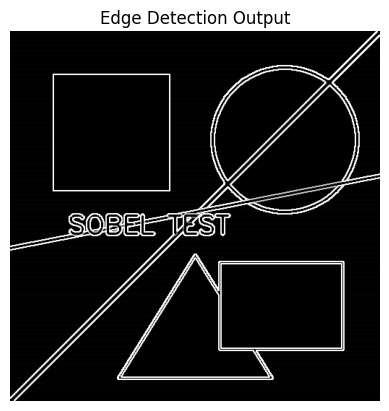

In [18]:
import cv2
from matplotlib import pyplot as plt

# Read and display the output image
output_image_path = '/content/output_sobel.jpeg'
output_image = cv2.imread(output_image_path, cv2.IMREAD_GRAYSCALE)  # Use IMREAD_GRAYSCALE if it's a single-channel image

# Display the image
plt.imshow(output_image, cmap='gray')
plt.title('Edge Detection Output')
plt.axis('off')  # Hide the axes
plt.show()
